In [10]:
import import_ipynb

import genetic_algorithm
import NSGA2
import simulated_annealing
from accuracy import calc_accuracy
from knn_evaluator import evaluate_knn
import pandas as pd
#import read_data
#import read_madelon
#import read_toxicity

In [11]:
X_train_toxicity = pd.read_csv("../oral_toxicity/X_train.csv")
X_validation_toxicity = pd.read_csv("../oral_toxicity/X_validation.csv")
y_train_toxicity = pd.read_csv('../oral_toxicity/y_train.csv').to_numpy().ravel()
y_validation_toxicity  = pd.read_csv('../oral_toxicity/y_validation.csv').to_numpy().ravel()

In [4]:
# type(y_validation_toxicity.to_numpy().ravel())

0.9242529534398888 0.0498046875
0.9263377345378735 0.05078125
0.9221681723419041 0.0400390625
0.935371785962474 0.0869140625
0.9277275886031967 0.0751953125
0.936761640027797 0.125
0.9291174426685198 0.0830078125


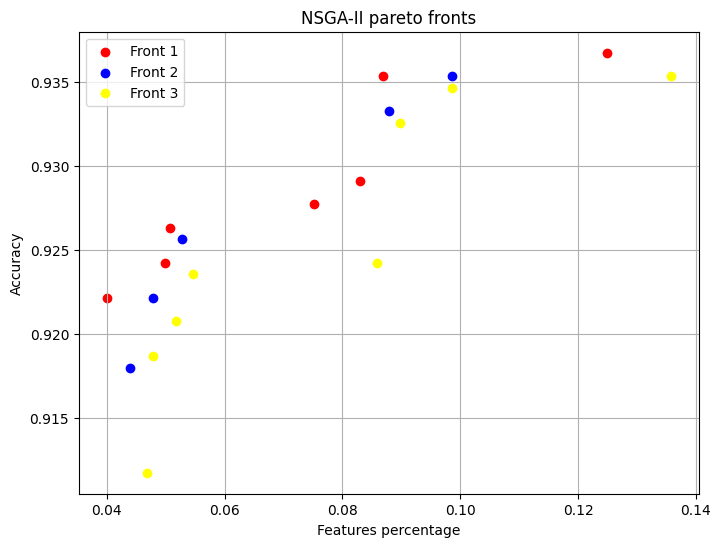

In [12]:
nsga = NSGA2.NSGA2(X_train_toxicity, y_train_toxicity, X_validation_toxicity, y_validation_toxicity, calc_accuracy_fn=evaluate_knn,
                   population_size=20, num_generations=3, feature_probability=0.05)
pareto = nsga.run()

In [13]:
sa =simulated_annealing.Simulated_Annealing(30,pareto[0].code,0.5,X_train_toxicity,y_train_toxicity,X_validation_toxicity,y_validation_toxicity,evaluate_knn)
sol, fitness,selected_percentage=sa.run()

In [14]:
fitness

0.9378440703179292

In [15]:
selected_percentage

0.052734375

In [11]:
ga = genetic_algorithm.GA( X_train_toxicity ,y_train_toxicity ,X_validation_toxicity,y_validation_toxicity,calc_accuracy_fn= evaluate_knn , population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 10)
selected_features, fitness, history = ga.run()

No improvement for 10 generations


In [15]:
#type(X_train_toxicity[X_train_toxicity.columns[selected_features]].to_numpy())

numpy.ndarray

In [16]:
X_test_toxicity = pd.read_csv("../oral_toxicity/X_test.csv")
y_test_toxicity = pd.read_csv("../oral_toxicity/y_test.csv").to_numpy().ravel()

In [17]:
evaluate_knn(selected_features,X_train_toxicity,y_train_toxicity,X_test_toxicity,y_test_toxicity)

0.9199555308504724

In [3]:
X_train_d = pd.read_csv("data/X_train.csv")
X_validation_d = pd.read_csv("data/X_validation.csv")

y_train_d = pd.read_csv("data/y_train.csv").to_numpy().ravel()
y_validation_d = pd.read_csv("data/y_validation.csv").to_numpy().ravel()

In [18]:
ga = genetic_algorithm.GA( X_train_toxicity ,y_train_toxicity ,X_validation_toxicity,y_validation_toxicity,calc_accuracy_fn= calc_accuracy , population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 10)
selected_features, fitness, history = ga.run()

No improvement for 10 generations
